# PEPE Hourly Trading Forecast Regression

This notebook builds a lagged hourly forecasting model for PEPE returns using Binance spot crypto data, yfinance hourly market proxies, BTC funding, BTC DVOL, and lower-frequency FRED macro variables forward-filled to the hourly grid. Predictors are lagged before backtesting so the strategy only uses information available before the target hour. The notebook reports model fit first, then strategy returns, risk metrics, cumulative return charts, and trade markers.


## Setup and hourly data configuration


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Setup
project_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "refresh_data.py").exists() and (path / "data").exists()
)
time_interval = "1H"
raw_data_dir = project_root / "data" / "raw" / "binance_daily"
data_path = raw_data_dir / f"binance_spot_{time_interval}_ohlcv_combined.csv"
fred_data_path = project_root / "data" / "raw" / "fred_macro" / "fred_macro_1D_combined.csv"
yfinance_data_path = project_root / "data" / "raw" / "yfinance_market" / f"yfinance_market_{time_interval}_ohlcv_combined.csv"
btc_funding_path = project_root / "data" / "raw" / "binance_funding" / f"BTCUSDT_funding_rate_{time_interval}.csv"
btc_dvol_path = project_root / "data" / "raw" / "deribit_dvol" / f"BTC_DVOL_{time_interval}.csv"

coin_order = ["PEPE", "BTC", "ETH", "SOL", "BNB", "XRP", "DOGE", "SHIB"]
target = "PEPE"
coin_colors = {
    "PEPE": "green",
    "BTC": "orange",
    "ETH": "grey",
    "SOL": "purple",
    "BNB": "gold",
    "XRP": "navy",
    "DOGE": "red",
    "SHIB": "brown",
}


## Load Binance hourly crypto data


In [2]:
# Load downloaded Binance spot OHLCV data
df = pd.read_csv(data_path, parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["coin"] = df["symbol"].str.replace("USDT", "", regex=False)

numeric_columns = ["open", "high", "low", "close", "volume"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

close_prices = df.pivot(index="timestamp", columns="coin", values="close").sort_index()
close_prices = close_prices[coin_order].replace([np.inf, -np.inf], np.nan)

open_prices = df.pivot(index="timestamp", columns="coin", values="open").sort_index()
high_prices = df.pivot(index="timestamp", columns="coin", values="high").sort_index()
low_prices = df.pivot(index="timestamp", columns="coin", values="low").sort_index()
volume_from = df.pivot(index="timestamp", columns="coin", values="volume").sort_index()

open_prices = open_prices[coin_order].replace([np.inf, -np.inf], np.nan)
high_prices = high_prices[coin_order].replace([np.inf, -np.inf], np.nan)
low_prices = low_prices[coin_order].replace([np.inf, -np.inf], np.nan)
volume_from = volume_from[coin_order].replace([np.inf, -np.inf], np.nan)


## Build hourly returns and aligned external factors


Simple cumulative return:
coin                           PEPE       BTC       ETH       SOL       BNB       XRP      DOGE      SHIB
timestamp                                                                                                
2026-07-29 04:00:00+00:00 -0.737799 -0.014325 -0.403479 -0.560232 -0.011009  0.835258 -0.402692 -0.708386
2026-07-29 05:00:00+00:00 -0.735885 -0.012800 -0.401282 -0.558855 -0.009148  0.844090 -0.402184 -0.705845
2026-07-29 06:00:00+00:00 -0.734928 -0.007125 -0.398890 -0.556460 -0.006557  0.847317 -0.400660 -0.706480
2026-07-29 07:00:00+00:00 -0.735885 -0.005193 -0.397472 -0.555383 -0.005391  0.851732 -0.399052 -0.705845
2026-07-29 08:00:00+00:00 -0.737799 -0.007982 -0.400374 -0.557538 -0.007757  0.844939 -0.402692 -0.707751



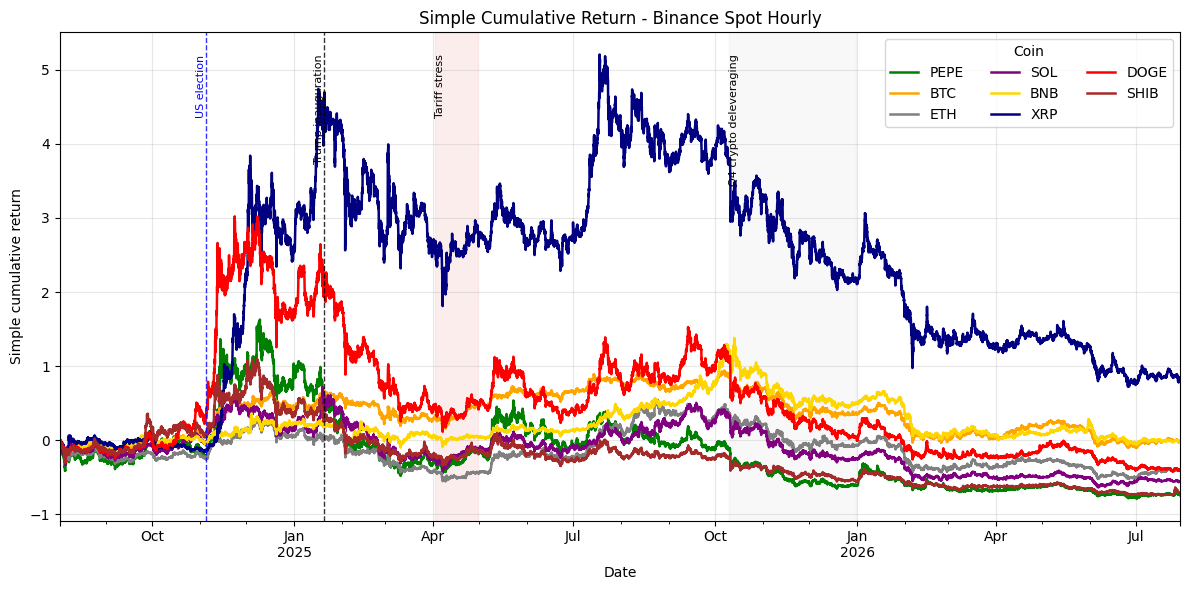

In [3]:
# Build returns and hourly aligned factor inputs
raw_returns = close_prices.pct_change(fill_method=None)
raw_returns = raw_returns[coin_order].replace([np.inf, -np.inf], np.nan)
for coin in coin_order:
    first_valid_timestamp = close_prices[coin].first_valid_index()
    if first_valid_timestamp is not None:
        raw_returns.loc[first_valid_timestamp, coin] = 0.0

log_returns = np.log(close_prices / close_prices.shift(1))
log_returns = log_returns[coin_order].replace([np.inf, -np.inf], np.nan)
for coin in coin_order:
    first_valid_timestamp = close_prices[coin].first_valid_index()
    if first_valid_timestamp is not None:
        log_returns.loc[first_valid_timestamp, coin] = 0.0

fred_data = pd.read_csv(fred_data_path, parse_dates=["date"])
fred_data["date"] = pd.to_datetime(fred_data["date"], utc=True)
fred_data["value"] = pd.to_numeric(fred_data["value"], errors="coerce")
fred_features = fred_data.pivot(index="date", columns="factor", values="value").sort_index()
fred_features = fred_features.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

yfinance_data = pd.read_csv(yfinance_data_path, parse_dates=["date"])
yfinance_data["date"] = pd.to_datetime(yfinance_data["date"], utc=True).dt.floor("h")
yfinance_data["close"] = pd.to_numeric(yfinance_data["close"], errors="coerce")
yfinance_closes = yfinance_data.pivot(index="date", columns="factor", values="close").sort_index()
yfinance_closes = yfinance_closes.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)
yfinance_log_returns = np.log(yfinance_closes / yfinance_closes.shift(1)).replace([np.inf, -np.inf], np.nan)

btc_funding = pd.read_csv(btc_funding_path, parse_dates=["date"])
btc_funding["date"] = pd.to_datetime(btc_funding["date"], utc=True)
btc_funding["funding_rate_sum"] = pd.to_numeric(btc_funding["funding_rate_sum"], errors="coerce")
btc_funding = btc_funding.set_index("date").sort_index()
btc_funding = btc_funding.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

btc_dvol = pd.read_csv(btc_dvol_path)
dvol_time_column = "timestamp" if "timestamp" in btc_dvol.columns else "date"
btc_dvol[dvol_time_column] = pd.to_datetime(btc_dvol[dvol_time_column], utc=True)
btc_dvol["close"] = pd.to_numeric(btc_dvol["close"], errors="coerce")
btc_dvol = btc_dvol.set_index(dvol_time_column).sort_index()
btc_dvol = btc_dvol.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

cumulative_returns = np.exp(log_returns.cumsum()) - 1
simple_cumulative_returns = (1 + raw_returns).cumprod() - 1

# print("Simple cumulative return:")
# print(simple_cumulative_returns.tail())
# print()
print("Simple cumulative return:")
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(simple_cumulative_returns.tail())
print()


fig, ax = plt.subplots(figsize=(12, 6))
simple_cumulative_returns.plot(
    ax=ax,
    linewidth=1.8,
    color=[coin_colors.get(coin) for coin in simple_cumulative_returns.columns],
)

chart_start = simple_cumulative_returns.index.min()
chart_end = simple_cumulative_returns.index.max()
event_y = simple_cumulative_returns.max().max()

event_spans = [
    {"label": "Tariff stress", "start": "2025-04-02", "end": "2025-04-30", "color": "lightcoral"},
    {"label": "Q4 crypto deleveraging", "start": "2025-10-10", "end": "2025-12-31", "color": "lightgrey"},
]

event_lines = [
    {"label": "US election", "date": "2024-11-05", "color": "blue"},
    {"label": "Trump inauguration", "date": "2025-01-20", "color": "black"},
]

for event in event_spans:
    start = pd.Timestamp(event["start"], tz="UTC")
    end = pd.Timestamp(event["end"], tz="UTC")
    if end < chart_start or start > chart_end:
        continue
    visible_start = max(start, chart_start)
    visible_end = min(end, chart_end)
    ax.axvspan(visible_start, visible_end, color=event["color"], alpha=0.14)
    ax.text(visible_start, event_y, event["label"], rotation=90, va="top", ha="left", fontsize=8, color="black")

for event in event_lines:
    date = pd.Timestamp(event["date"], tz="UTC")
    if date < chart_start or date > chart_end:
        continue
    ax.axvline(date, color=event["color"], linewidth=1.0, linestyle="--", alpha=0.8)
    ax.text(date, event_y, event["label"], rotation=90, va="top", ha="right", fontsize=8, color=event["color"])

plt.title("Simple Cumulative Return - Binance Spot Hourly")
plt.xlabel("Date")
plt.ylabel("Simple cumulative return")
plt.grid(True, alpha=0.3)
plt.legend(title="Coin", ncols=3)
plt.tight_layout()
plt.show()


## Build lagged trading feature matrix


In [4]:
# Build lagged feature matrix for trading-style hourly forecast testing
# - target PEPE is the current hourly log return
# - predictors are lagged so they use information known before the target hour
features = pd.DataFrame(index=log_returns.index)
# Crypto features
features["BTC_lag1"] = log_returns["BTC"].shift(1)
features["ETH_lag1"] = log_returns["ETH"].shift(1)
features["SOL_lag1"] = log_returns["SOL"].shift(1)
features["BNB_lag1"] = log_returns["BNB"].shift(1)
features["XRP_lag1"] = log_returns["XRP"].shift(1)
features["DOGE_lag1"] = log_returns["DOGE"].shift(1)
features["SHIB_lag1"] = log_returns["SHIB"].shift(1)
# PEPE features
features["PEPE_lag1"] = log_returns["PEPE"].shift(1)
features["PEPE_lag2"] = log_returns["PEPE"].shift(2)
features["PEPE_lag3"] = log_returns["PEPE"].shift(3)
features["PEPE_lag5"] = log_returns["PEPE"].shift(5)
features["PEPE_momentum_7h_lag1"] = log_returns["PEPE"].rolling(7).sum().shift(1)
features["PEPE_momentum_14h_lag1"] = log_returns["PEPE"].rolling(14).sum().shift(1)
features["PEPE_volatility_7h_lag1"] = log_returns["PEPE"].rolling(7).std().shift(1)
features["PEPE_volatility_14h_lag1"] = log_returns["PEPE"].rolling(14).std().shift(1)
features["PEPE_volume_change_lag1"] = np.log(volume_from["PEPE"] / volume_from["PEPE"].shift(1)).shift(1)
features["PEPE_range_lag1"] = ((high_prices["PEPE"] - low_prices["PEPE"]) / close_prices["PEPE"]).shift(1)
# BTC features
features["BTC_volatility_14h_lag1"] = log_returns["BTC"].rolling(14).std().shift(1)
features["BTC_range_lag1"] = ((high_prices["BTC"] - low_prices["BTC"]) / close_prices["BTC"]).shift(1)
features["BTC_funding_rate_sum_lag1"] = btc_funding["funding_rate_sum"].shift(1)
if btc_dvol["close"].notna().sum() >= 200:
    features["BTC_DVOL_change_lag1"] = btc_dvol["close"].diff().shift(1)
else:
    print("Skipping BTC_DVOL_change_lag1: insufficient hourly overlap.")
# Slow macro features, forward-filled from FRED
features["M2_30d_change_lag1"] = np.log(fred_features["m2_money_supply"] / fred_features["m2_money_supply"].shift(24 * 30)).shift(1)
features["SOFR_change_lag1"] = fred_features["sofr"].diff().shift(1)
features["DFF_change_lag1"] = fred_features["effective_fed_funds_rate"].diff().shift(1)
# Hourly market proxy ETF features
features["QQQ_lag1"] = yfinance_log_returns["nasdaq_100_etf"].shift(1)
features["SPY_lag1"] = yfinance_log_returns["sp500_etf"].shift(1)
features["IEF_lag1"] = yfinance_log_returns["treasury_7_10y_etf"].shift(1)
features["TLT_lag1"] = yfinance_log_returns["treasury_20y_etf"].shift(1)
features["UUP_lag1"] = yfinance_log_returns["us_dollar_index_proxy"].shift(1)
features["HYG_lag1"] = yfinance_log_returns["high_yield_credit_proxy"].shift(1)
features["VXX_lag1"] = yfinance_log_returns["vix_futures_proxy"].shift(1)
# Technical Indicators
trading_indicators = pd.DataFrame(index=log_returns.index)
trading_indicators["PEPE_SMA12h_lag1"] = log_returns["PEPE"].rolling(12).mean().shift(1)
trading_indicators["PEPE_SMA26h_lag1"] = log_returns["PEPE"].rolling(26).mean().shift(1)
pepe_close_change = close_prices["PEPE"].diff()
pepe_gain = pepe_close_change.clip(lower=0)
pepe_loss = -pepe_close_change.clip(upper=0)
pepe_avg_gain_14h = pepe_gain.rolling(14).mean()
pepe_avg_loss_14h = pepe_loss.rolling(14).mean()
trading_indicators["PEPE_RSI_14h_lag1"] = (100 - (100 / (1 + pepe_avg_gain_14h / pepe_avg_loss_14h))).shift(1)

pepe_bb_middle_20h = close_prices["PEPE"].rolling(20).mean()
pepe_bb_std_20h = close_prices["PEPE"].rolling(20).std()
pepe_bb_upper_20h = pepe_bb_middle_20h + 2 * pepe_bb_std_20h
pepe_bb_lower_20h = pepe_bb_middle_20h - 2 * pepe_bb_std_20h
trading_indicators["PEPE_BB_percent_b_20h_lag1"] = (
    (close_prices["PEPE"] - pepe_bb_lower_20h) / (pepe_bb_upper_20h - pepe_bb_lower_20h)
).shift(1)
features = pd.concat([features, trading_indicators], axis=1)

model_data = pd.concat([log_returns[target].rename(target), features], axis=1).dropna()
trading_indicator_table = trading_indicators.reindex(model_data.index)

print("Model data:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.expand_frame_repr", False
):
    print(model_data.head(10))
print()
print("Trading indicators:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.expand_frame_repr", False
):
    print(trading_indicator_table.head())
print()
print("Dependent Variable is current-hour PEPE log return.")
print("All predictors are lagged to avoid using information from the target hour.")
print("FRED macro series are lower frequency and forward-filled onto hourly timestamps.")


Model data:
                               PEPE  BTC_lag1  ETH_lag1  SOL_lag1  BNB_lag1  XRP_lag1  DOGE_lag1  SHIB_lag1  PEPE_lag1  PEPE_lag2  PEPE_lag3  PEPE_lag5  PEPE_momentum_7h_lag1  PEPE_momentum_14h_lag1  PEPE_volatility_7h_lag1  PEPE_volatility_14h_lag1  PEPE_volume_change_lag1  PEPE_range_lag1  BTC_volatility_14h_lag1  BTC_range_lag1  BTC_funding_rate_sum_lag1  BTC_DVOL_change_lag1  M2_30d_change_lag1  SOFR_change_lag1  DFF_change_lag1  QQQ_lag1  SPY_lag1  IEF_lag1  TLT_lag1  UUP_lag1  HYG_lag1  VXX_lag1  PEPE_SMA12h_lag1  PEPE_SMA26h_lag1  PEPE_RSI_14h_lag1  PEPE_BB_percent_b_20h_lag1
timestamp                                                                                                                                                                                                                                                                                                                                                                                                     

In [15]:
## Feature correlation diagnostics
print(features.isna().sum().sort_values(ascending=False).to_string())
print()

feature_count = features.shape[1]
print(f"Number of model features: {feature_count}")

M2_30d_change_lag1            1441
PEPE_SMA26h_lag1                26
PEPE_BB_percent_b_20h_lag1      20
HYG_lag1                        15
PEPE_RSI_14h_lag1               15
VXX_lag1                        15
QQQ_lag1                        15
IEF_lag1                        15
SPY_lag1                        15
TLT_lag1                        15
UUP_lag1                        15
PEPE_momentum_14h_lag1          14
BTC_volatility_14h_lag1         14
PEPE_volatility_14h_lag1        14
PEPE_SMA12h_lag1                12
PEPE_volatility_7h_lag1          7
PEPE_momentum_7h_lag1            7
PEPE_lag5                        5
PEPE_lag3                        3
SOFR_change_lag1                 2
DFF_change_lag1                  2
BTC_DVOL_change_lag1             2
PEPE_lag2                        2
PEPE_volume_change_lag1          2
SOL_lag1                         1
BTC_lag1                         1
ETH_lag1                         1
BTC_range_lag1                   1
PEPE_range_lag1     

## Fit forecast models


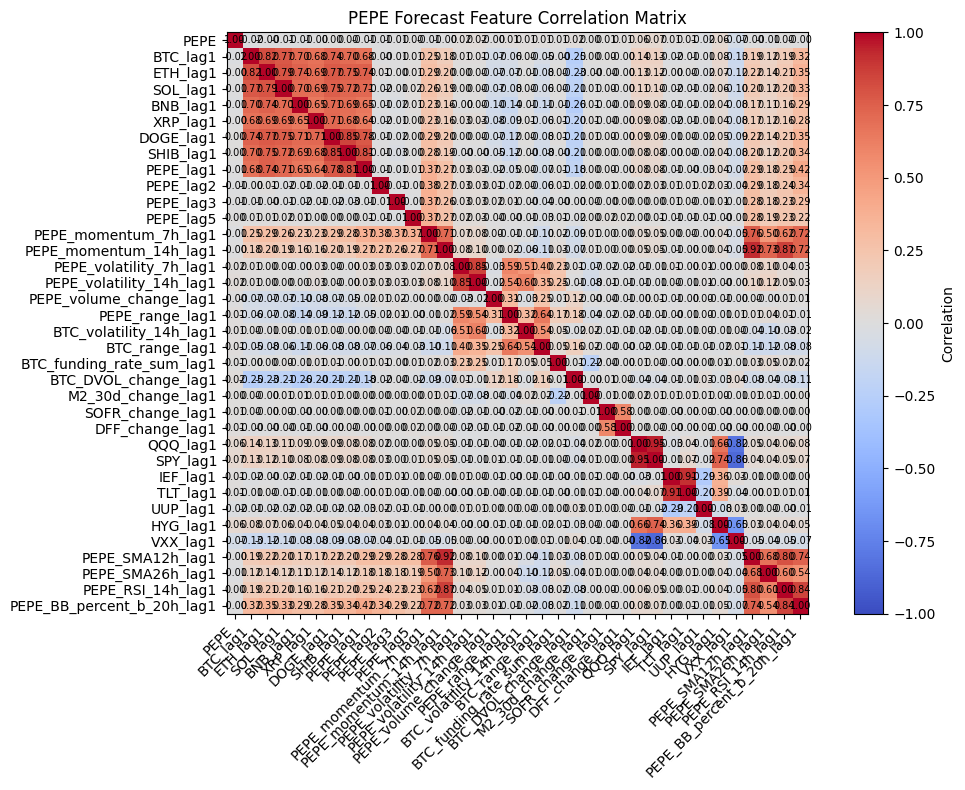

In [6]:
# Correlation matrix
correlation_matrix = model_data.corr()

plt.figure(figsize=(11, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("PEPE Forecast Feature Correlation Matrix")

for row_index, row_name in enumerate(correlation_matrix.index):
    for column_index, column_name in enumerate(correlation_matrix.columns):
        value = correlation_matrix.loc[row_name, column_name]
        plt.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

## Regression fit diagnostics


In [17]:
# Linear, Ridge, and ElasticNet regression
feature_columns = list(features.columns)
split_idx = int(len(model_data) * 0.8)

train_data = model_data.iloc[:split_idx]
test_data = model_data.iloc[split_idx:]

X_train = sm.add_constant(train_data[feature_columns], has_constant="add")
y_train = train_data[target]
X_test = sm.add_constant(test_data[feature_columns], has_constant="add")
y_test = test_data[target]

model = sm.OLS(y_train, X_train).fit()
y_pred = model.predict(X_test)

train_r2 = model.rsquared
adjusted_train_r2 = 1 - (1 - train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
test_r2 = r2_score(y_test, y_pred)
adjusted_test_r2 = 1 - (1 - test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
pred_corr = np.corrcoef(y_test, y_pred)[0, 1]

cv_r2s = []
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(train_data):
    cv_X_train = sm.add_constant(train_data.iloc[train_idx][feature_columns], has_constant="add")
    cv_y_train = train_data.iloc[train_idx][target]
    cv_X_val = sm.add_constant(train_data.iloc[val_idx][feature_columns], has_constant="add")
    cv_y_val = train_data.iloc[val_idx][target]
    cv_model = sm.OLS(cv_y_train, cv_X_train).fit()
    cv_pred = cv_model.predict(cv_X_val)
    cv_r2s.append(r2_score(cv_y_val, cv_pred))

coefficients = model.params.rename("coefficient")


print()
print(model.summary())

ridge_X_train = train_data[feature_columns]
ridge_X_test = test_data[feature_columns]
ridge_alphas = [0.01, 0.1, 1, 10, 100, 300, 1000, 3000, 10000]

ridge_cv_results = []

for alpha in ridge_alphas:
    alpha_cv_r2s = []
    for train_idx, val_idx in tscv.split(train_data):
        cv_X_train = train_data.iloc[train_idx][feature_columns]
        cv_y_train = train_data.iloc[train_idx][target]
        cv_X_val = train_data.iloc[val_idx][feature_columns]
        cv_y_val = train_data.iloc[val_idx][target]
        cv_ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        cv_ridge_model.fit(cv_X_train, cv_y_train)
        alpha_cv_r2s.append(r2_score(cv_y_val, cv_ridge_model.predict(cv_X_val)))
    ridge_cv_results.append({"alpha": alpha, "cv_r2_mean": np.mean(alpha_cv_r2s)})

ridge_cv_results = pd.DataFrame(ridge_cv_results)
best_ridge_alpha = ridge_cv_results.loc[ridge_cv_results["cv_r2_mean"].idxmax(), "alpha"]
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=best_ridge_alpha))
ridge_model.fit(ridge_X_train, y_train)
ridge_y_pred = ridge_model.predict(ridge_X_test)

ridge_train_r2 = ridge_model.score(ridge_X_train, y_train)
ridge_adjusted_train_r2 = 1 - (1 - ridge_train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
ridge_test_r2 = r2_score(y_test, ridge_y_pred)
ridge_adjusted_test_r2 = 1 - (1 - ridge_test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_y_pred))
ridge_pred_corr = np.corrcoef(y_test, ridge_y_pred)[0, 1]

ridge_coefficients = pd.Series(
    ridge_model.named_steps["ridge"].coef_,
    index=feature_columns,
    name="coefficient",
)

elastic_net_alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
elastic_net_l1_ratios = [0.1, 0.5, 0.9]
elastic_net_cv_results = []

for alpha in elastic_net_alphas:
    for l1_ratio in elastic_net_l1_ratios:
        alpha_cv_r2s = []
        for train_idx, val_idx in tscv.split(train_data):
            cv_X_train = train_data.iloc[train_idx][feature_columns]
            cv_y_train = train_data.iloc[train_idx][target]
            cv_X_val = train_data.iloc[val_idx][feature_columns]
            cv_y_val = train_data.iloc[val_idx][target]
            cv_elastic_net_model = make_pipeline(
                StandardScaler(),
                ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000),
            )
            cv_elastic_net_model.fit(cv_X_train, cv_y_train)
            alpha_cv_r2s.append(r2_score(cv_y_val, cv_elastic_net_model.predict(cv_X_val)))
        elastic_net_cv_results.append(
            {
                "alpha": alpha,
                "l1_ratio": l1_ratio,
                "cv_r2_mean": np.mean(alpha_cv_r2s),
            }
        )

elastic_net_cv_results = pd.DataFrame(elastic_net_cv_results)
best_elastic_net_params = elastic_net_cv_results.loc[elastic_net_cv_results["cv_r2_mean"].idxmax()]
elastic_net_model = make_pipeline(
    StandardScaler(),
    ElasticNet(
        alpha=best_elastic_net_params["alpha"],
        l1_ratio=best_elastic_net_params["l1_ratio"],
        max_iter=100000,
    ),
)
elastic_net_model.fit(ridge_X_train, y_train)
elastic_net_y_pred = elastic_net_model.predict(ridge_X_test)

elastic_net_train_r2 = elastic_net_model.score(ridge_X_train, y_train)
elastic_net_adjusted_train_r2 = 1 - (1 - elastic_net_train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
elastic_net_test_r2 = r2_score(y_test, elastic_net_y_pred)
elastic_net_adjusted_test_r2 = 1 - (1 - elastic_net_test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
elastic_net_rmse = np.sqrt(mean_squared_error(y_test, elastic_net_y_pred))
elastic_net_pred_corr = np.corrcoef(y_test, elastic_net_y_pred)[0, 1]
elastic_net_nonzero_coefficients = np.count_nonzero(elastic_net_model.named_steps["elasticnet"].coef_)

elastic_net_coefficients = pd.Series(
    elastic_net_model.named_steps["elasticnet"].coef_,
    index=feature_columns,
    name="coefficient",
)

model_accuracy_comparison = pd.DataFrame(
    [
        {
            "model": "OLS",
            "alpha": np.nan,
            "l1_ratio": np.nan,
            "nonzero_coef": len(feature_columns),
            "train_r2": train_r2,
            "adj_train_r2": adjusted_train_r2,
            "test_r2": test_r2,
            "adj_test_r2": adjusted_test_r2,
            "rmse": rmse,
            "pred_corr": pred_corr,
            "cv_r2_mean": np.mean(cv_r2s),
        },
        {
            "model": "Ridge",
            "alpha": best_ridge_alpha,
            "l1_ratio": np.nan,
            "nonzero_coef": np.count_nonzero(ridge_model.named_steps["ridge"].coef_),
            "train_r2": ridge_train_r2,
            "adj_train_r2": ridge_adjusted_train_r2,
            "test_r2": ridge_test_r2,
            "adj_test_r2": ridge_adjusted_test_r2,
            "rmse": ridge_rmse,
            "pred_corr": ridge_pred_corr,
            "cv_r2_mean": ridge_cv_results["cv_r2_mean"].max(),
        },
        {
            "model": "ElasticNet",
            "alpha": best_elastic_net_params["alpha"],
            "l1_ratio": best_elastic_net_params["l1_ratio"],
            "nonzero_coef": elastic_net_nonzero_coefficients,
            "train_r2": elastic_net_train_r2,
            "adj_train_r2": elastic_net_adjusted_train_r2,
            "test_r2": elastic_net_test_r2,
            "adj_test_r2": elastic_net_adjusted_test_r2,
            "rmse": elastic_net_rmse,
            "pred_corr": elastic_net_pred_corr,
            "cv_r2_mean": elastic_net_cv_results["cv_r2_mean"].max(),
        },
    ]
)




                            OLS Regression Results                            
Dep. Variable:                   PEPE   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     3.772
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           4.23e-13
Time:                        16:41:47   Log-Likelihood:                 37525.
No. Observations:               12793   AIC:                        -7.498e+04
Df Residuals:                   12757   BIC:                        -7.471e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const              

### Model accuracy comparison and ElasticNet coefficients

Elastic Net coefficients are shown directly below the model comparison so the selected features are easy to inspect.


In [8]:
print("Model accuracy comparison")
print(model_accuracy_comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

elastic_net_selected_coefficients = (
    elastic_net_coefficients[elastic_net_coefficients.ne(0)]
    .rename("coefficient")
    .reset_index()
    .rename(columns={"index": "feature"})
)
elastic_net_selected_coefficients["abs_coefficient"] = elastic_net_selected_coefficients["coefficient"].abs()
elastic_net_selected_coefficients = elastic_net_selected_coefficients.sort_values(
    "abs_coefficient",
    ascending=False,
).reset_index(drop=True)

print()
print("ElasticNet selected coefficients")
print(elastic_net_selected_coefficients.to_string(index=False, float_format=lambda value: f"{value:.6g}"))


Model accuracy comparison
     model        alpha  l1_ratio  nonzero_coef  train_r2  adj_train_r2   test_r2  adj_test_r2     rmse  pred_corr  cv_r2_mean
       OLS          NaN       NaN            35  0.010244      0.007528 -0.009707    -0.020880 0.008236   0.037162   -0.016648
     Ridge 10000.000000       NaN            35  0.008013      0.005291 -0.001227    -0.012306 0.008201   0.042092    0.001707
ElasticNet     0.001000  0.500000             2  0.003466      0.000732  0.002371    -0.008668 0.008187   0.050304    0.000973

ElasticNet selected coefficients
 feature  coefficient  abs_coefficient
SPY_lag1  0.000217133      0.000217133
VXX_lag1 -0.000200515      0.000200515


## Strategy results, cumulative returns, and trades


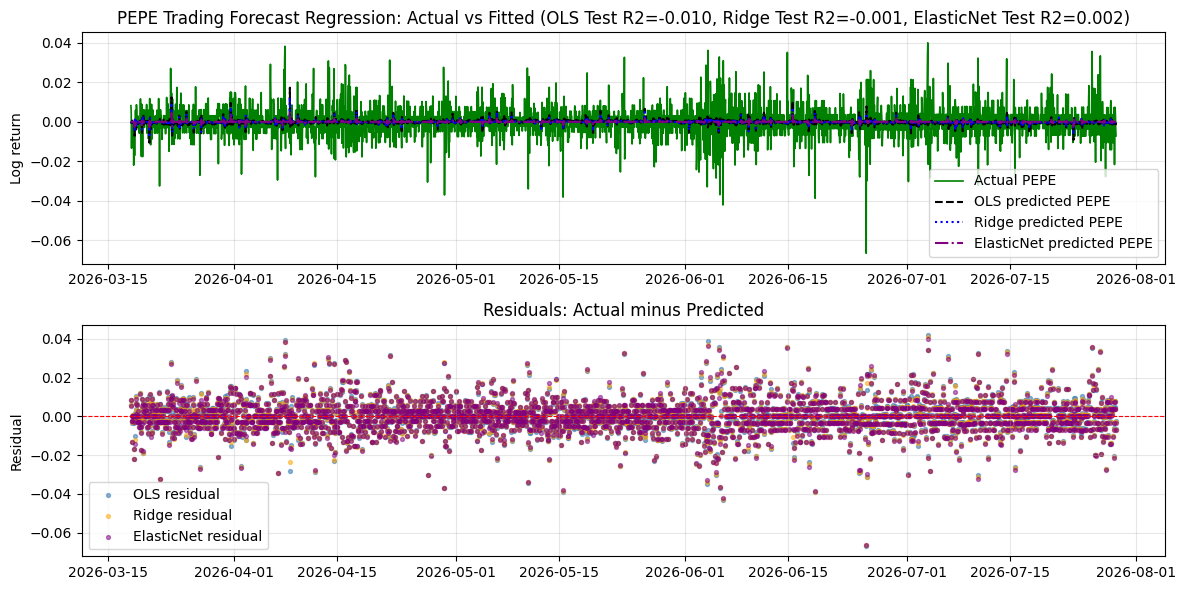

In [9]:
# Regression chart
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(test_data.index, y_test, label="Actual PEPE", color="green", linewidth=1.2)
axes[0].plot(test_data.index, y_pred, label="OLS predicted PEPE", color="black", linestyle="--")
axes[0].plot(test_data.index, ridge_y_pred, label="Ridge predicted PEPE", color="blue", linestyle=":")
axes[0].plot(test_data.index, elastic_net_y_pred, label="ElasticNet predicted PEPE", color="purple", linestyle="-.")
axes[0].set_title(
    f"PEPE Trading Forecast Regression: Actual vs Fitted "
    f"(OLS Test R2={test_r2:.3f}, Ridge Test R2={ridge_test_r2:.3f}, "
    f"ElasticNet Test R2={elastic_net_test_r2:.3f})"
)
axes[0].set_ylabel("Log return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
ridge_residuals = y_test - ridge_y_pred
elastic_net_residuals = y_test - elastic_net_y_pred
axes[1].scatter(test_data.index, residuals, s=8, color="steelblue", alpha=0.6, label="OLS residual")
axes[1].scatter(test_data.index, ridge_residuals, s=8, color="orange", alpha=0.5, label="Ridge residual")
axes[1].scatter(test_data.index, elastic_net_residuals, s=8, color="purple", alpha=0.5, label="ElasticNet residual")
axes[1].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[1].set_title("Residuals: Actual minus Predicted")
axes[1].set_ylabel("Residual")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Trading Backtest Results OOS



Strategy metrics table
     model  trade_number  cumulative_return      cagr  sharpe_ratio  max_drawdown  variance  sortino_ratio  directional_accuracy
       OLS           985           0.833771  4.261778      2.164601     -0.314885  0.000067       2.986952              0.412316
     Ridge           861           1.277721  8.527168      2.939188     -0.281219  0.000067       4.145966              0.422319
ElasticNet           381           2.127755 21.705093      4.073397     -0.227572  0.000067       5.806681              0.424195

Test period
Start: 2026-03-18  -  End: 2026-07-29
Hours/rows: 3,199
Days: 133.29


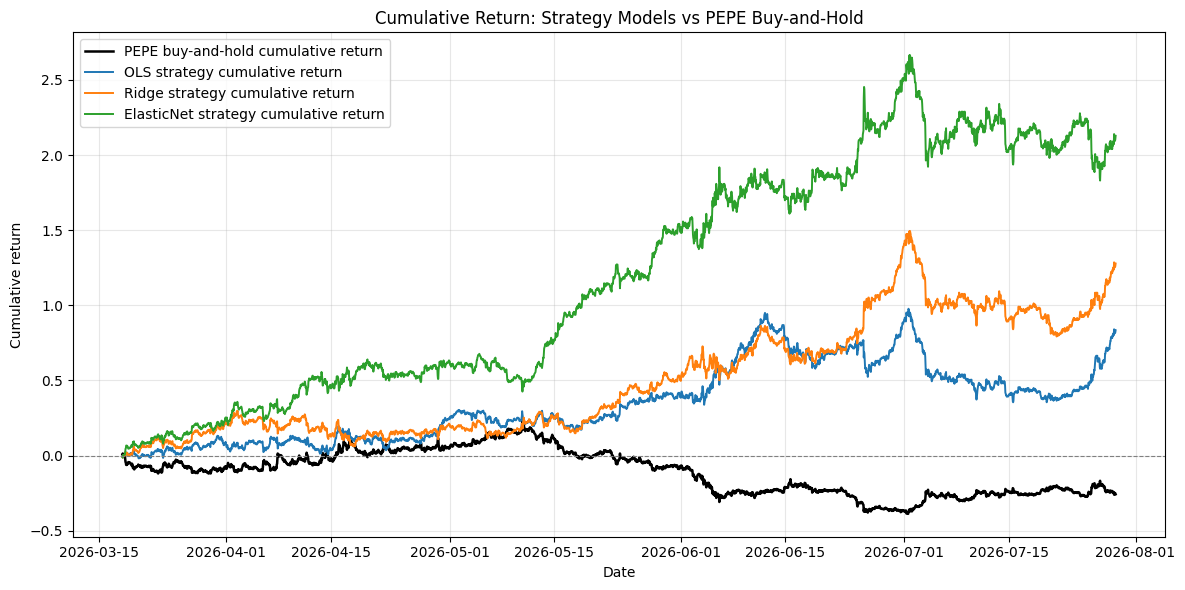

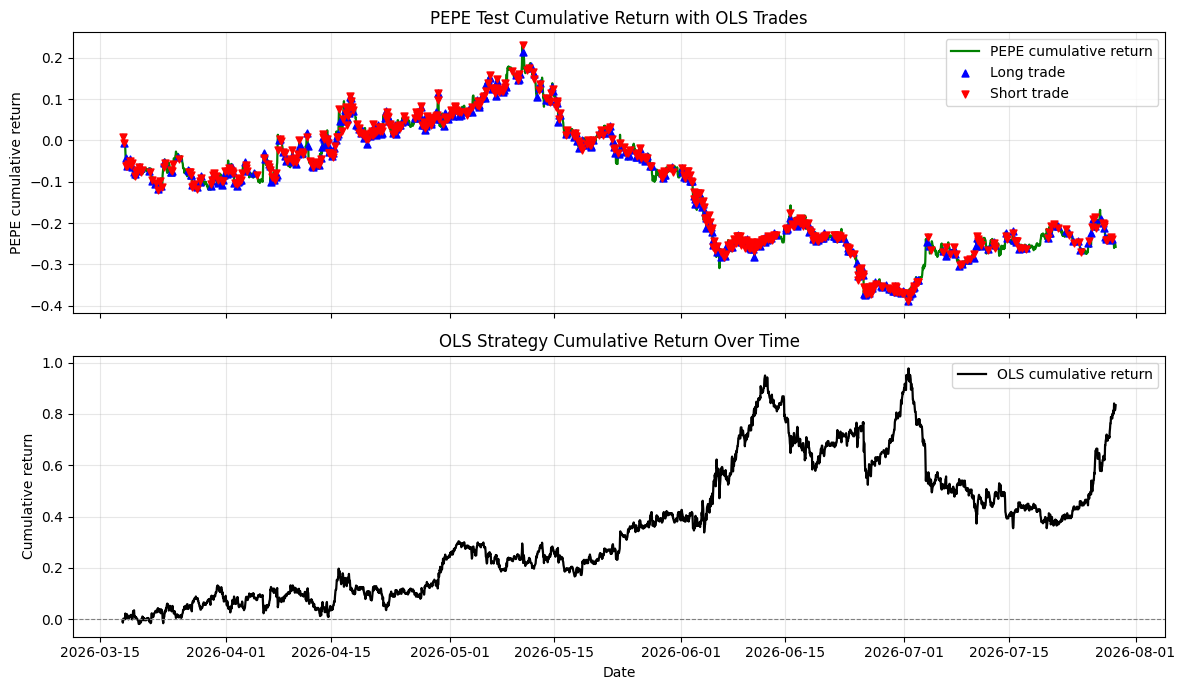

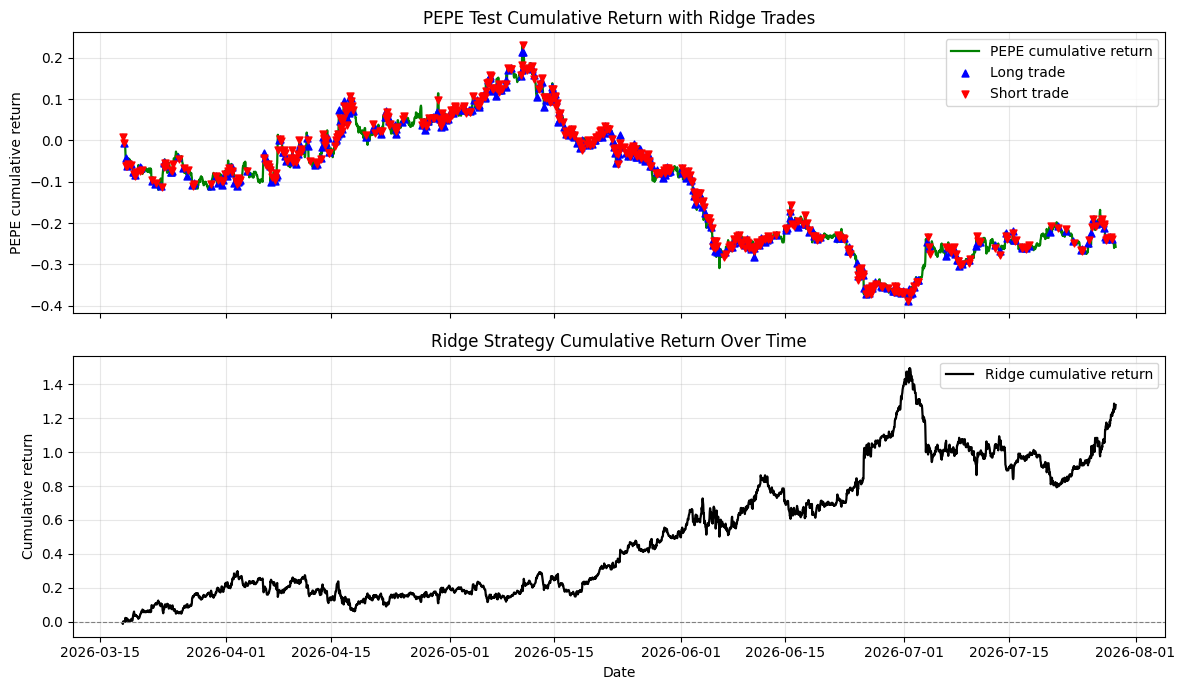

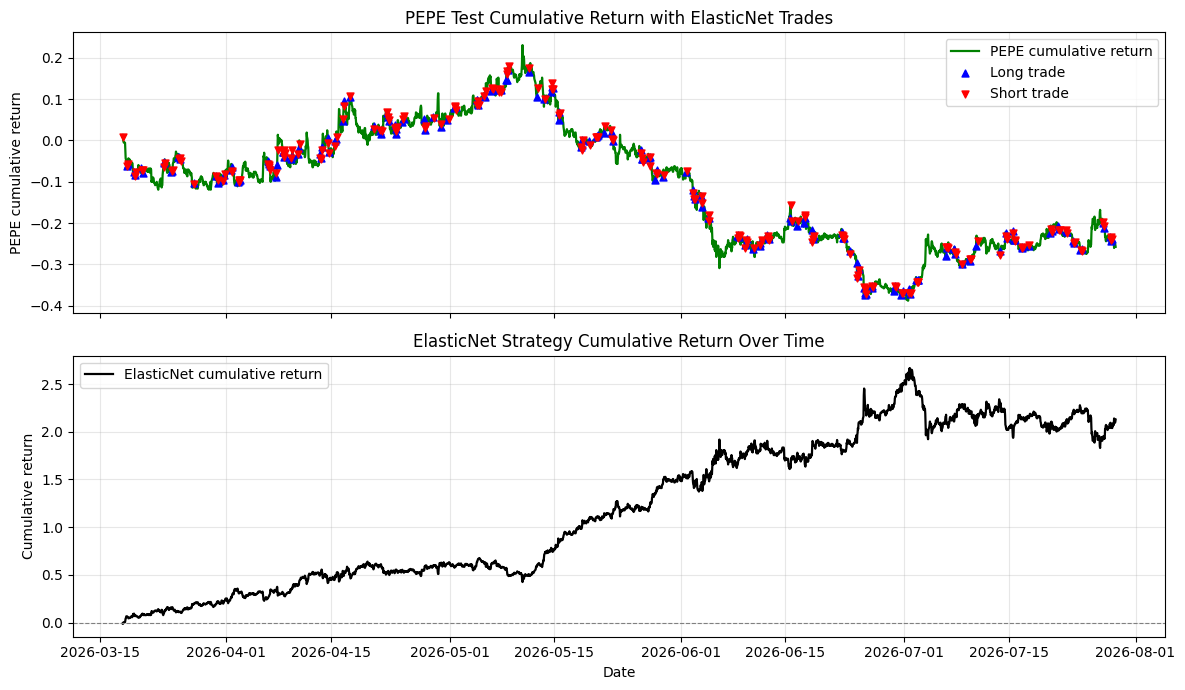

In [29]:
annual_periods = 24 * 365
strategy_metric_rows = []
strategy_series = {}
prediction_sets = {
    "OLS": pd.Series(y_pred, index=y_test.index),
    "Ridge": pd.Series(ridge_y_pred, index=y_test.index),
    "ElasticNet": pd.Series(elastic_net_y_pred, index=y_test.index),
}

for model_name, predicted_returns in prediction_sets.items():
    signal = np.sign(predicted_returns).replace(0, np.nan).ffill().fillna(0)
    trade_events = signal.ne(signal.shift(1).fillna(0))
    strategy_log_returns = signal * y_test
    strategy_equity = np.exp(strategy_log_returns.cumsum())
    strategy_drawdown = strategy_equity / strategy_equity.cummax() - 1
    downside_returns = strategy_log_returns[strategy_log_returns < 0]
    return_std = strategy_log_returns.std()
    return_variance = strategy_log_returns.var()
    downside_std = downside_returns.std()
    strategy_series[model_name] = pd.DataFrame(
        {
            "actual_log_return": y_test,
            "predicted_log_return": predicted_returns,
            "signal": signal,
            "trade_event": trade_events,
            "strategy_log_return": strategy_log_returns,
            "strategy_equity": strategy_equity,
            "strategy_cumulative_pnl": strategy_equity - 1,
            "strategy_drawdown": strategy_drawdown,
        }
    )

    strategy_metric_rows.append(
        {
            "model": model_name,
            "trade_number": int(trade_events.sum()),
            "cumulative_return": strategy_equity.iloc[-1] - 1 if len(strategy_equity) else np.nan,
            "cagr": np.exp(strategy_log_returns.mean() * annual_periods) - 1,
            "sharpe_ratio": strategy_log_returns.mean() / return_std * np.sqrt(annual_periods) if return_std > 0 else np.nan,
            "max_drawdown": strategy_drawdown.min(),
            "variance": return_variance,
            "sortino_ratio": (
                strategy_log_returns.mean() / downside_std * np.sqrt(annual_periods) if downside_std > 0 else np.nan
            ),
            "directional_accuracy": (np.sign(predicted_returns) == np.sign(y_test)).mean(),
        }
    )

strategy_metrics = pd.DataFrame(strategy_metric_rows).set_index("model")

model_comparison = pd.DataFrame(
    [
        {
            "model": "OLS",
            "alpha": np.nan,
            "l1_ratio": np.nan,
            "nonzero_coefficients": len(feature_columns),
            "trade_number": strategy_metrics.loc["OLS", "trade_number"],
            "cumulative_return": strategy_metrics.loc["OLS", "cumulative_return"],
            "cagr": strategy_metrics.loc["OLS", "cagr"],
            "sharpe_ratio": strategy_metrics.loc["OLS", "sharpe_ratio"],
            "max_drawdown": strategy_metrics.loc["OLS", "max_drawdown"],
            "variance": strategy_metrics.loc["OLS", "variance"],
            "sortino_ratio": strategy_metrics.loc["OLS", "sortino_ratio"],
            "directional_accuracy": strategy_metrics.loc["OLS", "directional_accuracy"],
            "train_r2": train_r2,
            "adjusted_train_r2": adjusted_train_r2,
            "test_r2": test_r2,
            "adjusted_test_r2": adjusted_test_r2,
            "rmse": rmse,
            "prediction_correlation": pred_corr,
            "cv_r2_mean": np.mean(cv_r2s),
        },
        {
            "model": "Ridge",
            "alpha": best_ridge_alpha,
            "l1_ratio": np.nan,
            "nonzero_coefficients": np.count_nonzero(ridge_model.named_steps["ridge"].coef_),
            "trade_number": strategy_metrics.loc["Ridge", "trade_number"],
            "cumulative_return": strategy_metrics.loc["Ridge", "cumulative_return"],
            "cagr": strategy_metrics.loc["Ridge", "cagr"],
            "sharpe_ratio": strategy_metrics.loc["Ridge", "sharpe_ratio"],
            "max_drawdown": strategy_metrics.loc["Ridge", "max_drawdown"],
            "variance": strategy_metrics.loc["Ridge", "variance"],
            "sortino_ratio": strategy_metrics.loc["Ridge", "sortino_ratio"],
            "directional_accuracy": strategy_metrics.loc["Ridge", "directional_accuracy"],
            "train_r2": ridge_train_r2,
            "adjusted_train_r2": ridge_adjusted_train_r2,
            "test_r2": ridge_test_r2,
            "adjusted_test_r2": ridge_adjusted_test_r2,
            "rmse": ridge_rmse,
            "prediction_correlation": ridge_pred_corr,
            "cv_r2_mean": ridge_cv_results["cv_r2_mean"].max(),
        },
        {
            "model": "ElasticNet",
            "alpha": best_elastic_net_params["alpha"],
            "l1_ratio": best_elastic_net_params["l1_ratio"],
            "nonzero_coefficients": elastic_net_nonzero_coefficients,
            "trade_number": strategy_metrics.loc["ElasticNet", "trade_number"],
            "cumulative_return": strategy_metrics.loc["ElasticNet", "cumulative_return"],
            "cagr": strategy_metrics.loc["ElasticNet", "cagr"],
            "sharpe_ratio": strategy_metrics.loc["ElasticNet", "sharpe_ratio"],
            "max_drawdown": strategy_metrics.loc["ElasticNet", "max_drawdown"],
            "variance": strategy_metrics.loc["ElasticNet", "variance"],
            "sortino_ratio": strategy_metrics.loc["ElasticNet", "sortino_ratio"],
            "directional_accuracy": strategy_metrics.loc["ElasticNet", "directional_accuracy"],
            "train_r2": elastic_net_train_r2,
            "adjusted_train_r2": elastic_net_adjusted_train_r2,
            "test_r2": elastic_net_test_r2,
            "adjusted_test_r2": elastic_net_adjusted_test_r2,
            "rmse": elastic_net_rmse,
            "prediction_correlation": elastic_net_pred_corr,
            "cv_r2_mean": elastic_net_cv_results["cv_r2_mean"].max(),
        },
    ]
)

model_accuracy_comparison = model_comparison[
    [
        "model",
        "alpha",
        "l1_ratio",
        "nonzero_coefficients",
        "train_r2",
        "adjusted_train_r2",
        "test_r2",
        "adjusted_test_r2",
        "rmse",
        "prediction_correlation",
        "cv_r2_mean",
    ]
]
pepe_test_cumulative_returns = np.exp(y_test.cumsum()) - 1
pepe_buy_hold_cumulative_return = pepe_test_cumulative_returns.iloc[-1] if len(pepe_test_cumulative_returns) else np.nan

model_trade_comparison = model_comparison[
    [
        "model",
        "trade_number",
        "cumulative_return",
        "cagr",
        "sharpe_ratio",
        "max_drawdown",
        "variance",
        "sortino_ratio",
        "directional_accuracy",
    ]
]

print()
print("Strategy metrics table")
print(model_trade_comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))
print()
test_start = y_test.index.min().date()
test_end = y_test.index.max().date()
test_period_hours = len(y_test)
test_period_days = test_period_hours / 24

print("Test period")
print(f"Start: {test_start}"," - ", f"End: {test_end}")
print(f"Hours/rows: {test_period_hours:,}")
print(f"Days: {test_period_days:.2f}")


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    pepe_test_cumulative_returns.index,
    pepe_test_cumulative_returns,
    label="PEPE buy-and-hold cumulative return",
    color="black",
    linewidth=1.8,
)
for model_name, model_strategy in strategy_series.items():
    ax.plot(
        model_strategy.index,
        model_strategy["strategy_cumulative_pnl"],
        label=f"{model_name} strategy cumulative return",
        linewidth=1.4,
    )
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Return: Strategy Models vs PEPE Buy-and-Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for model_name, model_strategy in strategy_series.items():
    trade_log = model_strategy.loc[model_strategy["trade_event"]].copy()
    long_trades = trade_log[trade_log["signal"].eq(1)]
    short_trades = trade_log[trade_log["signal"].eq(-1)]
    flat_trades = trade_log[trade_log["signal"].eq(0)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(
        pepe_test_cumulative_returns.index,
        pepe_test_cumulative_returns,
        label="PEPE cumulative return",
        color="green",
        linewidth=1.6,
    )
    axes[0].scatter(
        long_trades.index,
        pepe_test_cumulative_returns.reindex(long_trades.index),
        marker="^",
        color="blue",
        s=25,
        label="Long trade",
        zorder=3,
    )
    axes[0].scatter(
        short_trades.index,
        pepe_test_cumulative_returns.reindex(short_trades.index),
        marker="v",
        color="red",
        s=25,
        label="Short trade",
        zorder=3,
    )
    if not flat_trades.empty:
        axes[0].scatter(
            flat_trades.index,
            pepe_test_cumulative_returns.reindex(flat_trades.index),
            marker="o",
            color="black",
            s=28,
            label="Flat trade",
            zorder=3,
        )
    axes[0].set_title(f"PEPE Test Cumulative Return with {model_name} Trades")
    axes[0].set_ylabel("PEPE cumulative return")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        model_strategy.index,
        model_strategy["strategy_cumulative_pnl"],
        label=f"{model_name} cumulative return",
        color="black",
        linewidth=1.6,
    )
    axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
    axes[1].set_title(f"{model_name} Strategy Cumulative Return Over Time")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Cumulative return")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Notebook-only outputs

This notebook displays model accuracy, strategy metrics, trade markers, PnL charts, and diagnostics inline. It does not save forecast CSV, TXT, or PNG output files.